# 02. Supervisor 패턴 — 핸드오프 도구 방식

> 이 노트북은 Supervisor가 Worker 에이전트를 조율할 때 **핸드오프 도구**(`transfer_to_X`)를 호출하는 방식을 다뤄요. 같은 Supervisor 아키텍처를 **구조화 출력**(`RouteResponse(next=...)`) 방식으로 구현하는 레슨은 **`04-Multi-Agent-Supervisor.ipynb`** 에 있어요 — 둘은 경쟁이 아니라 **같은 패턴의 두 구현 전략**이에요.

| 축 | 02 (이 노트북) | 04-Multi-Agent-Supervisor |
|----|----------------|---------------------------|
| 다음 노드 선택 방법 | 핸드오프 **도구 호출** | **구조화 출력** 라우팅 |
| 핵심 API | `create_supervisor`, `create_handoff_tool`, `Command(goto=...)` | `RouteResponse(next: Literal[...])`, `with_structured_output` |
| 제어 흐름 | LLM이 도구를 통해 Command 반환 | LLM이 스키마에 맞춰 직접 라우트 결정 |
| 장점 | 표준 tool-calling 모델과 자연스러움 | 라우팅 메타데이터를 깔끔하게 관찰 가능 |

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `langgraph-supervisor` 라이브러리를 활용하여 Supervisor 에이전트를 빠르게 구현할 수 있어요
2. `create_handoff_tool`과 `Command` 패턴을 이해하고 커스텀 Supervisor를 직접 만들 수 있어요
3. `task_description` 핸드오프로 명시적 작업 지시를 에이전트에 전달할 수 있어요
4. `StateGraph`로 Supervisor + Worker 에이전트 구조를 직접 조립할 수 있어요

## 사전 지식

- 이전 노트북: `01-Multi-Agent-Overview.ipynb`에서 배운 5가지 멀티에이전트 패턴
- `create_agent`로 에이전트 생성하는 방법 (Part 5 참고)
- LangGraph `StateGraph`, `Command`, `START/END` 기초

## Supervisor 패턴이란?

**Supervisor 패턴**은 복잡한 작업을 여러 전문 에이전트에게 분배하고 조정하는 멀티에이전트 아키텍처예요.

> 🎯 **강의 포인트**: Supervisor 패턴은 실제 회사의 **프로젝트 매니저(PM)**와 같아요. PM은 직접 코딩하거나 디자인하지 않아요. 대신 "이 작업은 백엔드팀에서, 저 작업은 프론트엔드팀에서" 하고 분배하고, 결과를 취합해서 보고하죠. Supervisor도 마찬가지로 직접 작업을 수행하지 않고, 핸드오프 도구로 적합한 전문가에게 **위임**만 해요.

### 핵심 구성 요소

| 구성 요소 | 역할 | 비유 | 특징 |
|-----------|------|------|------|
| **Supervisor** | 작업 위임 및 조정 | 프로젝트 매니저 | 핸드오프 도구로 워커 에이전트 호출 |
| **Worker Agent** | 전문 작업 실행 | 팀원 (개발자, 디자이너) | 자신의 도메인에만 집중 |
| **Handoff Tool** | 제어권 전달 | 업무 지시서 | `Command(goto=..., graph=PARENT)` 패턴 |
| **create_supervisor** | 빠른 구성 | 팀 빌더 키트 | `langgraph-supervisor` 라이브러리 제공 |

> 🔑 **핵심 개념**: Supervisor 패턴에서 에이전트 간 제어권 이동을 **핸드오프(Handoff)**라고 해요. "이 업무는 A팀에서 처리하고, 완료되면 B팀으로 넘기세요" 같은 방식이에요.

### 아키텍처 다이어그램

```mermaid
flowchart TD
    User([사용자 요청<br/>User Request])
    Supervisor[Supervisor<br/>작업 분석 및 위임]
    Research[Research Agent<br/>웹 검색 및 정보 수집]
    Math[Math Agent<br/>수학 계산 및 분석]
    Result([최종 응답<br/>Final Response])

    User --> Supervisor
    Supervisor -- 핸드오프 --> Research
    Supervisor -- 핸드오프 --> Math
    Research -- 결과 반환 --> Supervisor
    Math -- 결과 반환 --> Supervisor
    Supervisor --> Result

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class User,Result input
    class Supervisor process
    class Research,Math process
```

## 환경 설정

In [1]:
# !uv add langgraph_supervisor

In [2]:
# 환경 변수 로드 (.env 파일에서 API 키를 가져와요)
from dotenv import load_dotenv

load_dotenv(override=True)
# 환경 변수 로드 완료

True

In [3]:
# LangSmith 추적 설정 (실행 흐름을 시각화해서 확인할 수 있어요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-08-Supervisor"

# LangSmith 추적 설정 완료

## 헬퍼 함수 정의

여러 에이전트가 동시에 작업하는 멀티에이전트 시스템에서는 각 에이전트의 출력을 구분해서 보기 어려워요.
노드별로 구분선을 추가하여 가독성을 높이는 헬퍼 함수를 먼저 정의할게요.

In [4]:
# 메시지 출력 헬퍼 함수 정의
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    """개별 메시지를 포맷팅하여 출력하는 함수예요"""
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return
    # 서브그래프 메시지는 들여쓰기 적용
    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    """그래프 실행 결과의 메시지 업데이트를 노드별로 출력하는 함수예요"""
    is_subgraph = False

    # 튜플인 경우 서브그래프 업데이트 (subgraphs=True 옵션 사용 시)
    if isinstance(update, tuple):
        ns, update = update
        if len(ns) == 0:  # 부모 그래프 업데이트는 건너뜀
            return
        graph_id = ns[-1].split(":")[0]
        print(f"[서브그래프 {graph_id}로부터 업데이트]")
        is_subgraph = True

    # 각 노드의 업데이트를 순서대로 출력
    for node_name, node_update in update.items():
        update_label = f"[노드 {node_name}로부터 업데이트]"
        if is_subgraph:
            update_label = "\t" + update_label
        print(update_label)

        # 메시지 변환 및 출력
        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]  # 마지막 메시지만 표시

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)


# 헬퍼 함수 정의 완료

## 1. 워커 에이전트 생성

Supervisor에게 위임받을 전문 워커 에이전트를 먼저 만들어요.
두 가지 전문 에이전트를 만들 거예요:

1. **Research Agent**: Tavily 검색 API로 웹에서 정보를 수집해요
2. **Math Agent**: 사칙연산, 백분율 등 수학 계산을 수행해요

> 🔑 **핵심 개념**: `create_agent`의 `name` 파라미터가 매우 중요해요. 이 이름이 LangGraph 그래프의 **노드 이름**으로 사용되고, Supervisor가 핸드오프할 때 이 이름을 사용해요.

In [5]:
# Research Agent 생성 (웹 검색 전문)
import warnings
from langchain_tavily import TavilySearch
from langchain.agents import create_agent

warnings.filterwarnings("ignore")

# Tavily 웹 검색 도구 초기화 (최대 3개 결과 반환)
web_search = TavilySearch(max_results=3)

# Research Agent 생성
# name="research_agent" → 그래프 노드 이름이 됩니다
research_agent = create_agent(
    model="openai:gpt-4o-mini",  # 기본 모델: gpt-4o-mini (비용 효율적)
    tools=[web_search],
    system_prompt=(
        "당신은 웹 검색 전문 에이전트예요.\n"
        "사용자의 요청에 따라 최신 정보를 검색하고 정확한 데이터를 제공하세요.\n"
        "수학 계산은 하지 않아요 — 계산이 필요하면 수퍼바이저에게 알려주세요.\n"
        "한국어로 답변하세요."
    ),
    name="research_agent",  # 그래프 노드 이름으로 사용됩니다
)

# Research Agent 생성 완료
#   - 도구: TavilySearch (웹 검색)
#   - 역할: 인터넷에서 최신 정보 수집

In [6]:
# Math Agent 생성 (수학 계산 전문)


# 수학 도구 함수 정의
def add(a: float, b: float) -> float:
    """두 숫자를 더해요."""
    return a + b


def multiply(a: float, b: float) -> float:
    """두 숫자를 곱해요."""
    return a * b


def divide(a: float, b: float) -> float:
    """두 숫자를 나눠요. 0으로 나누면 무한대 반환."""
    if b == 0:
        return float("inf")
    return a / b


def percentage(value: float, total: float) -> float:
    """전체(total) 대비 값(value)의 백분율을 계산해요."""
    if total == 0:
        return 0.0
    return (value / total) * 100


# Math Agent 생성
# name="math_agent" → 그래프 노드 이름이 됩니다
math_agent = create_agent(
    model="openai:gpt-4o-mini",  # 기본 모델: gpt-4o-mini
    tools=[add, multiply, divide, percentage],
    system_prompt=(
        "당신은 수학 계산 전문 에이전트예요.\n"
        "산술 연산, 백분율 계산, 수치 비교 등을 수행하세요.\n"
        "웹 검색은 하지 않아요 — 정보 조사가 필요하면 수퍼바이저에게 알려주세요.\n"
        "계산 과정을 단계별로 보여주고, 한국어로 답변하세요."
    ),
    name="math_agent",  # 그래프 노드 이름으로 사용됩니다
)

# Math Agent 생성 완료
#   - 도구: add, multiply, divide, percentage
#   - 역할: 수학 계산 및 수치 분석

워커 에이전트가 잘 동작하는지 간단히 테스트해볼게요.

In [7]:
# Math Agent 단독 테스트
# Math Agent 테스트: (3 + 5) × 7
# ----------------------------------------

for chunk in math_agent.stream(
    {"messages": [{"role": "user", "content": "(3 + 5) 곱하기 7은 얼마인가요?"}]}
):
    pretty_print_messages(chunk)

[노드 model로부터 업데이트]
================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (call_DQChk75vvPjNfGAbvC06Lu6l)
 Call ID: call_DQChk75vvPjNfGAbvC06Lu6l
  Args:
    a: 3
    b: 5
[노드 tools로부터 업데이트]
================================= Tool Message =================================
Name: add

8.0
[노드 model로부터 업데이트]
================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  multiply (call_qGoVmGJLsOPAIGfhjx9ObC8P)
 Call ID: call_qGoVmGJLsOPAIGfhjx9ObC8P
  Args:
    a: 8
    b: 7
[노드 tools로부터 업데이트]
================================= Tool Message =================================
Name: multiply

56.0
[노드 model로부터 업데이트]
================================== Ai Message ==================================
Name: math_agent

(3 + 5) 곱하기 7의 결과는 56입니다.


## 2. create_supervisor로 빠르게 구현하기

`langgraph-supervisor` 라이브러리는 Supervisor 패턴을 빠르게 구현할 수 있도록 도와줘요.
`create_supervisor` 함수 하나로 핸드오프 도구 생성, 에이전트 연결, 그래프 구성이 자동으로 처리돼요.

> 💡 **실무 팁**: `langgraph-supervisor`는 별도 패키지예요. 설치하려면 `pip install langgraph-supervisor`를 실행하세요. V1 기준으로 이 패키지가 권장 방법이에요.

> ⚠️ **자주 하는 실수**: `output_mode="last_message"`로 설정하면 최종 메시지만 반환돼요. 에이전트 실행 과정을 모두 보고 싶다면 `output_mode="full_history"`를 사용하세요.

In [8]:
# langgraph-supervisor 라이브러리로 Supervisor 생성
from langgraph_supervisor import create_supervisor
from langchain.chat_models import init_chat_model

# Supervisor 생성
supervisor = create_supervisor(
    model=init_chat_model("openai:gpt-4o-mini"),  # Supervisor용 모델
    agents=[research_agent, math_agent],  # 관리할 워커 에이전트 목록
    system_prompt=(
        "당신은 두 전문 에이전트를 조율하는 수퍼바이저예요.\n\n"
        "에이전트 역할:\n"
        "- research_agent: 웹 검색과 정보 수집\n"
        "- math_agent: 수학 계산과 수치 분석\n\n"
        "규칙:\n"
        "- 작업을 직접 처리하지 않고 항상 전문 에이전트에게 위임하세요\n"
        "- 한 번에 하나의 에이전트만 호출하세요 (순차 처리)\n"
        "- 에이전트 결과를 종합하여 최종 답변을 제공하세요\n"
        "- 한국어로 답변하세요"
    ),
    add_handoff_back_messages=True,  # 에이전트 → Supervisor 복귀 메시지 자동 추가
    output_mode="full_history",  # 전체 실행 히스토리를 반환
).compile()  # 그래프 컴파일

# Supervisor 생성 완료
#   - add_handoff_back_messages=True: 에이전트 복귀 메시지 자동 추가
#   - output_mode='full_history': 전체 실행 과정 기록

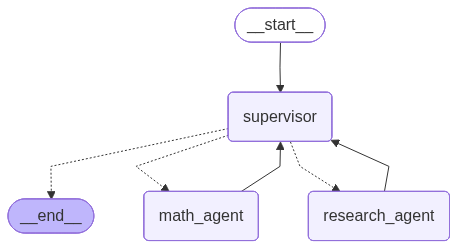

In [9]:
# 그래프 흐름: START → supervisor → (research_agent | math_agent) → supervisor → ... → END
# supervisor: 작업을 분석하고 핸드오프 도구로 적절한 워커 에이전트를 선택해요
# research_agent: 웹 검색으로 정보를 수집해요
# math_agent: 수학 계산을 수행해요
# 조건부 엣지: supervisor의 핸드오프 결정에 따라 워커 에이전트로 분기해요
from IPython.display import Image, display

display(Image(supervisor.get_graph().draw_mermaid_png()))

Research와 Math 에이전트를 모두 필요로 하는 복합 질문으로 테스트해볼게요.
Supervisor가 두 에이전트에게 순서대로 위임하는 과정을 확인할 수 있어요.

In [10]:
# Supervisor 복합 작업 테스트
# Research Agent: GDP 데이터 검색
# Math Agent: 비율 계산
# Supervisor 복합 작업 테스트
# ============================================================
# 질문: 2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %인지 계산해주세요
print("=" * 60, "\n")

for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "2024년 미국과 뉴욕주의 GDP를 찾고, 뉴욕주가 미국 전체 GDP의 몇 %를 차지하는지 계산해주세요.",
            }
        ]
    }
):
    pretty_print_messages(chunk, last_message=True)


[노드 supervisor로부터 업데이트]
================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent
[노드 research_agent로부터 업데이트]
================================= Tool Message =================================
Name: transfer_back_to_supervisor

Successfully transferred back to supervisor
[노드 supervisor로부터 업데이트]
================================== Ai Message ==================================
Name: supervisor

2024년 미국의 GDP는 약 26조 달러로 예상되며, 뉴욕주의 GDP는 약 2.3조 달러입니다. 따라서 뉴욕주는 미국 전체 GDP의 약 8.85%를 차지하고 있습니다. 추가적인 정보가 필요하시면 언제든지 말씀해 주세요!


## 3. 커스텀 Supervisor 직접 구현하기

이번에는 라이브러리 없이 Supervisor를 직접 만들어볼게요.
내부 동작 원리를 이해하면 더 복잡한 시스템도 자유롭게 설계할 수 있어요.

### 핸드오프 작동 방식

```mermaid
sequenceDiagram
    participant S as Supervisor
    participant H as Handoff Tool
    participant R as Research Agent

    S->>H: transfer_to_research_agent 호출
    H->>H: Command(goto="research_agent", graph=PARENT) 생성
    H-->>S: Command 반환
    Note over S,R: 그래프가 research_agent 노드로 이동
    R->>R: 작업 수행
    R-->>S: supervisor 노드로 복귀 (엣지 설정)
```

> 🔑 **핵심 개념**: `InjectedState`와 `InjectedToolCallId`는 LLM에게 노출되지 않는 주입(Inject) 마커예요. LLM이 호출할 때 이 파라미터는 보이지 않고, LangGraph가 자동으로 현재 상태와 도구 호출 ID를 주입해줘요.

> ⚠️ **자주 하는 실수**: `graph=Command.PARENT`를 빠뜨리면 안 돼요. 이 설정이 없으면 서브그래프 안에서 라우팅이 발생해요. 부모 그래프 레벨에서 에이전트 간 이동이 이루어지도록 반드시 명시해야 해요.

In [11]:
# 커스텀 핸드오프 도구 팩토리 함수 정의
from typing import Annotated
from langchain.tools import tool
from langchain_core.tools import InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.graph import MessagesState
from langgraph.types import Command


def create_handoff_tool(*, agent_name: str, description: str | None = None):
    """다른 에이전트로 제어권을 전달하는 핸드오프 도구를 생성하는 팩토리 함수예요"""
    # 도구 이름 = "transfer_to_{agent_name}" 형식
    name = f"transfer_to_{agent_name}"
    description = (
        description or f"{agent_name}에게 작업을 위임해요."
    )

    @tool(name, description=description)
    def handoff_tool(
        # InjectedState: 현재 그래프 상태를 자동으로 주입 (LLM에게는 보이지 않아요)
        state: Annotated[MessagesState, InjectedState],
        # InjectedToolCallId: 도구 호출 ID를 자동으로 주입 (LLM에게는 보이지 않아요)
        tool_call_id: Annotated[str, InjectedToolCallId],
    ) -> Command:
        """핸드오프를 실행하여 대상 에이전트로 제어권을 넘겨요"""
        # 핸드오프 성공 메시지 생성 (메시지 히스토리에 기록)
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": name,
            "tool_call_id": tool_call_id,
        }
        # Command: 다음으로 이동할 노드와 상태 업데이트를 정의해요
        return Command(
            goto=agent_name,  # 대상 에이전트 노드로 이동
            update={  # 메시지 히스토리에 핸드오프 메시지 추가
                **state,
                "messages": state["messages"] + [tool_message],
            },
            graph=Command.PARENT,  # 부모 그래프에서 라우팅 (중요!)
        )

    return handoff_tool


# Research Agent와 Math Agent로의 핸드오프 도구 생성
assign_to_research_agent = create_handoff_tool(
    agent_name="research_agent",
    description="웹 검색과 정보 수집 작업을 research_agent에게 위임해요.",
)

assign_to_math_agent = create_handoff_tool(
    agent_name="math_agent",
    description="수학 계산과 수치 분석 작업을 math_agent에게 위임해요.",
)

# 핸드오프 도구 생성 완료
print(f"  - {assign_to_research_agent.name}")
print(f"  - {assign_to_math_agent.name}")

  - transfer_to_research_agent
  - transfer_to_math_agent


In [12]:
# 커스텀 Supervisor 에이전트와 멀티에이전트 그래프 구성
from langgraph.graph import StateGraph, START, END

# Supervisor 에이전트 생성 (핸드오프 도구를 갖춘 조율자)
supervisor_agent = create_agent(
    model="openai:gpt-4o-mini",  # 기본 모델: gpt-4o-mini
    tools=[assign_to_research_agent, assign_to_math_agent],  # 핸드오프 도구 제공
    system_prompt=(
        "당신은 전문 에이전트들을 조율하는 수퍼바이저예요.\n\n"
        "사용 가능한 에이전트:\n"
        "1. research_agent: 웹 검색, 사실 확인, 정보 수집\n"
        "2. math_agent: 사칙연산, 백분율, 수치 분석\n\n"
        "조율 원칙:\n"
        "- 작업을 직접 처리하지 말고 적합한 에이전트에게 위임하세요\n"
        "- 순차 처리: 한 번에 하나의 에이전트만 호출하세요\n"
        "- 에이전트 결과를 종합해서 최종 답변을 만들어요\n"
        "- 한국어로 답변하세요"
    ),
    name="supervisor",
)

# StateGraph로 멀티에이전트 그래프 직접 조립
# destinations: 시각화를 위해 이동 가능한 노드를 명시해요
custom_supervisor = (
    StateGraph(MessagesState)
    .add_node(supervisor_agent, destinations=("research_agent", "math_agent", END))
    .add_node(research_agent)   # Research Agent 노드 추가
    .add_node(math_agent)       # Math Agent 노드 추가
    .add_edge(START, "supervisor")           # 시작 → Supervisor
    .add_edge("research_agent", "supervisor") # Research Agent → Supervisor (복귀)
    .add_edge("math_agent", "supervisor")     # Math Agent → Supervisor (복귀)
    .compile()
)

# 커스텀 Supervisor 그래프 구성 완료

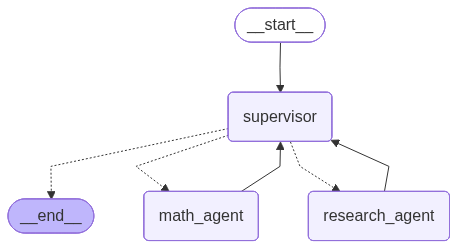

In [13]:
# 그래프 흐름: START → supervisor → (research_agent | math_agent) → supervisor → ... → END
# supervisor: 핸드오프 도구로 워커를 선택하고 작업을 위임해요
# research_agent / math_agent: 작업 수행 후 supervisor로 복귀해요
# 조건부 엣지: Command(goto=agent_name)로 에이전트 간 이동해요
from IPython.display import Image, display
display(Image(custom_supervisor.get_graph().draw_mermaid_png()))

In [14]:
# 커스텀 Supervisor 테스트 — 순수 수학 문제로 핸드오프 메커니즘 검증
# (웹 검색 없이 math_agent 단독 호출로 핸드오프 흐름을 확인해요)
# 커스텀 Supervisor 테스트
# ============================================================
# 질문: (12 + 8) × 5는 얼마인가요?
# 예상 흐름: Supervisor → math_agent 핸드오프 → 계산 결과 반환
print("=" * 60, "\n")

for chunk in custom_supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "(12 + 8) 곱하기 5는 얼마인가요? 계산 과정을 보여주세요.",
            }
        ]
    }
):
    pretty_print_messages(chunk, last_message=True)


[노드 supervisor로부터 업데이트]
================================= Tool Message =================================
Name: transfer_to_math_agent

Successfully transferred to math_agent
[노드 math_agent로부터 업데이트]
================================== Ai Message ==================================
Name: math_agent

계산 과정을 보여드리겠습니다.

1. 먼저 12와 8을 더합니다:
   \[
   12 + 8 = 20
   \]

2. 그 다음, 구해진 결과 20에 5를 곱합니다:
   \[
   20 \times 5 = 100
   \]

따라서, \((12 + 8) \times 5\)의 결과는 **100**입니다.
[노드 supervisor로부터 업데이트]
================================== Ai Message ==================================
Name: supervisor

결과적으로 \((12 + 8) \times 5\)는 **100**입니다. 계산 과정은 다음과 같습니다:

1. \(12 + 8 = 20\)
2. \(20 \times 5 = 100\)

궁금한 점이 있으면 말씀해 주세요!


## 4. 명시적 작업 지시 핸드오프 (Task Description Handoff)

지금까지는 Supervisor가 전체 메시지 히스토리를 에이전트에게 전달했어요.
하지만 메시지가 많아질수록 에이전트가 무엇을 해야 할지 찾기 어려워져요.

**Task Description Handoff**는 Supervisor가 명시적인 작업 설명을 직접 작성해서 전달하는 방식이에요.

> 🎯 **강의 포인트**: 일반 핸드오프는 **팀장이 회의록 전체를 팀원에게 보내는 것**과 같아요. Task Description 핸드오프는 **핵심 요약만 적어 보내는 것**이에요. "회의 내용 중에 GDP 데이터를 찾아서 비율을 계산해줘"라고 명확하게 지시하면, 팀원이 100페이지 회의록을 읽지 않아도 바로 작업에 착수할 수 있어요.

### 기존 방식 vs Task Description 방식

| 방식 | 에이전트가 받는 내용 | 비유 | 장점 | 단점 |
|------|---------------------|------|------|------|
| **기존 방식** | 전체 대화 히스토리 | 회의록 전체 전달 | 맥락 풍부 | 불필요한 내용 포함 |
| **Task Description** | Supervisor가 쓴 명시적 지시 | 핵심만 요약한 업무 지시서 | 정확하고 간결 | 지시 작성 비용 |

> 💡 **실무 팁**: `Send` 패턴을 사용하면 에이전트에게 전달할 상태를 완전히 새롭게 구성할 수 있어요. 에이전트는 전체 대화 히스토리 대신 Supervisor가 요약한 명확한 지시만 받아요. 이를 통해 에이전트 성능이 향상돼요.

In [ ]:
# Task Description Handoff 도구 팩토리 함수
from langgraph.types import Send


def create_task_description_handoff_tool(
    *, agent_name: str, description: str | None = None
):
    """명시적 작업 설명과 함께 핸드오프하는 도구를 생성해요"""
    name = f"transfer_to_{agent_name}"
    description = description or f"{agent_name}에게 상세한 작업 지시와 함께 위임해요."

    @tool(name, description=description)
    def handoff_tool(
        # task_description: LLM(Supervisor)이 직접 작성하는 작업 지시
        task_description: Annotated[
            str,
            "에이전트에게 전달할 구체적인 작업 설명이에요. 필요한 모든 맥락과 요구사항을 포함하세요.",
        ],
        # InjectedState: 현재 상태 주입 (LLM에게는 보이지 않아요)
        state: Annotated[MessagesState, InjectedState],
    ) -> Command:
        """명시적 작업 지시를 담아 에이전트로 핸드오프해요"""

        print(f"[{agent_name}] 에이전트가 해야 할 일 : {task_description}")
        # 작업 설명을 새 사용자 메시지로 변환 (전체 히스토리 대신 이것만 전달)
        task_description_message = {"role": "user", "content": task_description}
        # 에이전트에게 전달할 새로운 상태 (히스토리를 작업 설명으로 교체)
        agent_input = {**state, "messages": [task_description_message]}

        return Command(
            # Send: 특정 에이전트에게 특정 상태를 보내는 패턴이에요
            goto=[Send(agent_name, agent_input)],
            graph=Command.PARENT,
        )

    return handoff_tool


# 작업 설명 핸드오프 도구 생성
assign_research_with_task = create_task_description_handoff_tool(
    agent_name="research_agent",
    description="research_agent에게 구체적인 검색 지시와 함께 작업을 위임해요.",
)

assign_math_with_task = create_task_description_handoff_tool(
    agent_name="math_agent",
    description="math_agent에게 구체적인 계산 지시와 함께 작업을 위임해요.",
)

# Task Description 핸드오프 도구 생성 완료
#   - Supervisor가 에이전트별 맞춤 지시를 작성해서 전달해요

In [16]:
# Task Description 방식의 고급 Supervisor 그래프 구성

# Supervisor 에이전트 생성 (task_description을 직접 작성)
supervisor_with_task = create_agent(
    model="openai:gpt-4o-mini",
    tools=[assign_research_with_task, assign_math_with_task],
    system_prompt=(
        "당신은 명시적인 작업 지시를 통해 에이전트를 조율하는 수퍼바이저예요.\n\n"
        "작업 위임 방법:\n"
        "1. 에이전트에게 필요한 작업을 명확하게 설명하세요\n"
        "2. 필요한 데이터, 맥락, 기대 출력 형식을 포함하세요\n"
        "3. 에이전트가 추가 정보 없이 바로 실행할 수 있도록 완전한 지시를 제공하세요\n\n"
        "에이전트 역할:\n"
        "- research_agent: 웹 검색 및 정보 수집\n"
        "- math_agent: 수학 계산 및 수치 분석\n\n"
        "한국어로 답변하세요"
    ),
    name="supervisor",
)

# 고급 Supervisor 그래프 구성
advanced_supervisor = (
    StateGraph(MessagesState)
    .add_node(
        supervisor_with_task,
        destinations=("research_agent", "math_agent"),  # 이동 가능한 목적지 명시
    )
    .add_node(research_agent)
    .add_node(math_agent)
    .add_edge(START, "supervisor")
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    .compile()
)

# 고급 Supervisor (Task Description 방식) 생성 완료

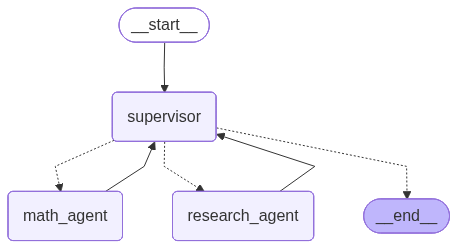

In [17]:
# 그래프 흐름: START → supervisor → (research_agent | math_agent) → supervisor → ... → END
# supervisor: Task Description(명시적 작업 지시)을 직접 작성해서 에이전트에 전달해요
# Send 패턴: 전체 히스토리 대신 Supervisor가 요약한 작업 지시만 에이전트에 전달해요
from IPython.display import Image, display
display(Image(advanced_supervisor.get_graph().draw_mermaid_png()))

In [18]:
# 고급 Supervisor 테스트 (subgraphs=True로 내부 실행도 추적)
# 고급 Supervisor 테스트 (서브그래프 실행 추적 포함)
# ============================================================

for chunk in advanced_supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "비트코인의 현재 가격과 1년 전 가격을 조사한 후, 1년간 가격 변동률을 계산해주세요.",
            }
        ]
    },
    subgraphs=True,  # 워커 에이전트 내부 실행 과정도 출력
):
    pretty_print_messages(chunk, last_message=True)

[research_agent] to 비트코인의 1년 전 가격을 조사해 주세요.
[research_agent] to 비트코인의 현재 가격을 조사해 주세요.
[서브그래프 supervisor로부터 업데이트]
	[노드 model로부터 업데이트]
	================================== Ai Message ==================================
	Name: supervisor
	Tool Calls:
	  transfer_to_research_agent (call_zhjbj620hwFpusabYJ2unEao)
	 Call ID: call_zhjbj620hwFpusabYJ2unEao
	  Args:
	    task_description: 비트코인의 현재 가격을 조사해 주세요.
	  transfer_to_research_agent (call_Auu7BTQ7UwsBpcg3I5q6ASwP)
	 Call ID: call_Auu7BTQ7UwsBpcg3I5q6ASwP
	  Args:
	    task_description: 비트코인의 1년 전 가격을 조사해 주세요.
[서브그래프 research_agent로부터 업데이트]
	[노드 model로부터 업데이트]
	================================== Ai Message ==================================
	Name: research_agent
	Tool Calls:
	  tavily_search (call_nGZTAvFLxrJ7740eHbI6X6FC)
	 Call ID: call_nGZTAvFLxrJ7740eHbI6X6FC
	  Args:
	    query: 비트코인 현재 가격
	    topic: general
[서브그래프 research_agent로부터 업데이트]
	[노드 tools로부터 업데이트]
	================================= Tool Message =============================

## 5. 실습 해설: 3-에이전트 Supervisor 만들기

아래 완성 예제는 기존 Research/Math 팀에 **Translator Agent**를 추가하고, 커스텀 핸드오프 도구와 `StateGraph`에 새 노드를 연결합니다.

In [19]:
# ============================================================
# 실습 해설: 번역가 에이전트를 추가하여 3-에이전트 Supervisor를 만들어요
#
# 예상 결과: "Artificial Intelligence"를 검색하고 한국어로 번역해달라는 질문에
#           research_agent와 translator_agent가 순서대로 동작해요.
# ============================================================

# 이 실습에서는 번역 흐름을 분명히 보기 위해 Research Agent가 영어 요약만 반환하도록 별도 인스턴스를 만들어요.
translation_research_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[web_search],
    system_prompt=(
        "You are a web research agent. Search for information when needed. "
        "Return a concise English summary only. Do not translate into Korean."
    ),
    name="research_agent",
)

translator_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[],
    system_prompt=(
        "당신은 영어와 한국어를 자연스럽게 오가는 전문 번역가예요. "
        "영어 원문을 강의 자료에 어울리는 명확한 한국어로 번역하세요."
    ),
    name="translator_agent",
)

assign_to_translator_agent = create_handoff_tool(
    agent_name="translator_agent",
    description="영어 → 한국어 번역 작업을 translator_agent에게 위임해요.",
)

three_agent_supervisor_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[assign_to_research_agent, assign_to_math_agent, assign_to_translator_agent],
    system_prompt=(
        "당신은 research_agent, math_agent, translator_agent를 조율하는 수퍼바이저예요.\n\n"
        "에이전트 역할:\n"
        "- research_agent: 영어로 웹 검색과 정보 수집\n"
        "- math_agent: 계산과 수치 분석\n"
        "- translator_agent: 영어 원문을 한국어로 번역\n\n"
        "규칙:\n"
        "- 직접 처리하지 말고 가장 적합한 에이전트에게 위임하세요.\n"
        "- 검색 후 한국어 번역이 필요한 요청은 반드시 research_agent → translator_agent 순서로 처리하세요.\n"
        "- translator_agent가 번역을 완료한 뒤에만 최종 답변을 작성하세요."
    ),
    name="supervisor",
)

three_agent_supervisor = (
    StateGraph(MessagesState)
    .add_node(three_agent_supervisor_agent, destinations=("research_agent", "math_agent", "translator_agent", END))
    .add_node(translation_research_agent)
    .add_node(math_agent)
    .add_node(translator_agent)
    .add_edge(START, "supervisor")
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    .add_edge("translator_agent", "supervisor")
    .compile()
)

print("3-에이전트 Supervisor 구성: research_agent → translator_agent 흐름 확인")
for chunk in three_agent_supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "Artificial Intelligence의 핵심 의미를 영어로 조사한 뒤, 그 영어 요약을 강의 자료용 한국어 문장으로 번역해주세요.",
            }
        ]
    }
):
    pretty_print_messages(chunk, last_message=True)

3-에이전트 Supervisor 구성: research_agent → translator_agent 흐름 확인
[노드 supervisor로부터 업데이트]
================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent
[노드 research_agent로부터 업데이트]
================================== Ai Message ==================================
Name: research_agent

Artificial Intelligence (AI) is a rapidly evolving field in computer science, characterized by systems designed to perform tasks that typically require human intelligence. AI encompasses various capabilities, including machine learning, which enables systems to improve their performance through data. AI can be classified into narrow AI, focused on specific tasks like virtual assistants, and artificial general intelligence (AGI), which aspires to perform all human intellectual tasks but remains theoretical. Key components of AI systems include machine learning, deep learning, and natural language processing, all contri

## 6. 실전 활용: 고객 지원 시스템

Supervisor 패턴을 실제 비즈니스 시나리오에 적용해볼게요.
3가지 전문 에이전트로 구성된 고객 지원 시스템이에요:

- **기술 지원 에이전트**: 시스템 오류, 연결 문제 처리
- **청구 지원 에이전트**: 인보이스, 결제, 환불 처리
- **일반 지원 에이전트**: 제품 정보, 영업 시간 등 안내

> 💡 **실무 팁**: Tool Calling 패턴(에이전트를 `@tool`로 래핑)도 Supervisor 패턴처럼 유용해요. 하위 에이전트를 단순히 함수처럼 호출하고 싶을 때 적합하고, 상태 관리가 단순한 경우에 사용해요.

In [20]:
# 고객 지원 시스템 - 에이전트 및 도구 정의
from langchain.chat_models import init_chat_model

base_model = init_chat_model("openai:gpt-4o-mini")


# --- 기술 지원 에이전트 ---
@tool
def check_system_status(system: str) -> str:
    """시스템 상태를 확인해요."""
    return f"시스템 '{system}'은 현재 정상 작동 중이에요."


@tool
def restart_service(service: str) -> str:
    """서비스를 재시작해요."""
    return f"서비스 '{service}'가 성공적으로 재시작되었어요."


tech_support_agent = create_agent(
    model=base_model,
    tools=[check_system_status, restart_service],
    system_prompt="당신은 기술 지원 전문가예요. 시스템 문제 해결 전에 항상 상태를 먼저 확인하세요. 한국어로 답변하세요.",
    name="tech_support",
)


# --- 청구 지원 에이전트 ---
@tool
def check_invoice(invoice_id: str) -> str:
    """인보이스 정보를 조회해요."""
    return f"인보이스 #{invoice_id}: 금액 100,000원, 상태: 결제 완료"


@tool
def process_refund(order_id: str) -> str:
    """환불을 처리해요."""
    return f"주문 #{order_id} 환불이 완료되었어요. 3-5 영업일 내에 환불됩니다."


billing_support_agent = create_agent(
    model=base_model,
    tools=[check_invoice, process_refund],
    system_prompt="당신은 청구 지원 전문가예요. 환불 전 항상 인보이스를 먼저 확인하세요. 한국어로 답변하세요.",
    name="billing_support",
)


# --- 일반 지원 에이전트 ---
general_support_agent = create_agent(
    model=base_model,
    tools=[],  # 일반 안내는 도구 없이 LLM이 처리
    system_prompt="당신은 친절한 고객 지원 담당자예요. 제품과 서비스에 대한 일반적인 질문에 답하세요. 한국어로 답변하세요.",
    name="general_support",
)

# 고객 지원 에이전트 3종 생성 완료

In [21]:
# 고객 지원 Supervisor 생성 (create_supervisor 라이브러리 활용)
from langgraph_supervisor import create_supervisor

customer_support_system = create_supervisor(
    model=base_model,
    agents=[tech_support_agent, billing_support_agent, general_support_agent],
    system_prompt=(
        "당신은 고객 지원 수퍼바이저예요. 고객 문의를 분석하여 올바른 전문가에게 연결하세요.\n\n"
        "- tech_support: 기술 문제, 오류, 시스템 장애\n"
        "- billing_support: 인보이스, 결제, 환불 요청\n"
        "- general_support: 제품 정보, 영업 시간, 일반 안내\n\n"
        "항상 가장 적합한 전문가에게 위임하고, 한국어로 답변하세요."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

# 고객 지원 Supervisor 시스템 생성 완료

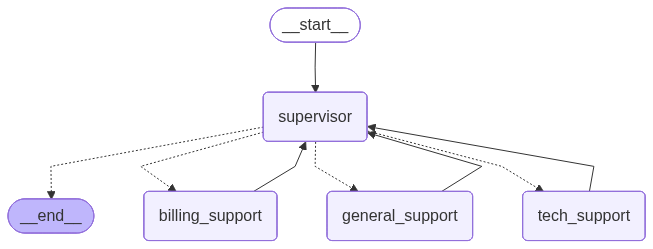

In [22]:
# 그래프 흐름: START → supervisor → (tech_support | billing_support | general_support) → supervisor → ... → END
# supervisor: 고객 문의 유형을 분석하고 전문 에이전트로 핸드오프해요
# tech_support: 기술 문제(시스템 상태 확인, 서비스 재시작)를 처리해요
# billing_support: 청구/결제(인보이스 조회, 환불 처리)를 처리해요
# general_support: 일반 안내(제품 정보, 영업 시간)를 처리해요
from IPython.display import Image, display
display(Image(customer_support_system.get_graph().draw_mermaid_png()))

In [23]:
# 고객 지원 시스템 테스트 - 3가지 유형의 문의
test_queries = [
    ("기술 문의", "앱이 계속 충돌해요. 로그인이 안 됩니다."),
    ("청구 문의", "주문 #99887에 대한 환불을 요청하고 싶어요."),
    ("일반 문의", "고객 지원 영업 시간이 언제인가요?"),
]

for query_type, query in test_queries:
    print(f"\n{'='*50}")
    print(f"[{query_type}] {query}")
    # ==================================================

    result = customer_support_system.invoke(
        {"messages": [{"role": "user", "content": query}]}
    )
    # 마지막 AI 메시지만 출력
    final_messages = [m for m in result["messages"] if hasattr(m, "type") and m.type == "ai"]
    if final_messages:
        print(f"\n최종 응답:\n{final_messages[-1].content}")


[기술 문의] 앱이 계속 충돌해요. 로그인이 안 됩니다.

최종 응답:
앱의 충돌 문제를 해결하기 위해 몇 가지 단계를 안내해 드렸습니다. 다시 시도한 후에도 문제가 지속된다면, 추가적인 도움이 필요할 수 있습니다. 다른 질문이나 필요한 도움 사항이 있으신가요?

[청구 문의] 주문 #99887에 대한 환불을 요청하고 싶어요.

최종 응답:
환불 진행이 완료되었습니다. 추가로 도와드릴 일이 있으면 말씀해 주세요.

[일반 문의] 고객 지원 영업 시간이 언제인가요?

최종 응답:
고객 지원 영업 시간은 일반적으로 월요일부터 금요일까지 오전 9시부터 오후 6시까지입니다. 그러나 특정 기업이나 서비스에 따라 다를 수 있으니, 정확한 정보를 원하신다면 해당 기업의 공식 웹사이트나 고객센터에 문의해 보시는 것이 좋습니다.


## Supervisor 구현 방식 비교

이 노트북에서 배운 세 가지 방식을 비교해볼게요:

| 방식 | 코드 양 | 유연성 | 추천 상황 |
|------|---------|--------|----------|
| **create_supervisor** | 적음 | 중간 | 빠른 프로토타이핑, 표준 패턴 |
| **커스텀 StateGraph** | 중간 | 높음 | 커스텀 로직, 세밀한 제어 |
| **Task Description** | 중간 | 높음 | 에이전트별 명확한 지시가 필요할 때 |

> 🎯 **강의 포인트**: 세 방식 모두 내부적으로는 동일한 원리(`Command` + 핸드오프)로 동작해요. `create_supervisor`는 편의 함수일 뿐이고, 커스텀 구현은 더 많은 제어권을 줘요. 실무에서는 처음에 `create_supervisor`로 시작하고, 필요할 때 커스텀 구현으로 전환하는 것을 추천해요.

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **create_supervisor**: `langgraph-supervisor` 라이브러리의 편의 함수로, 에이전트 목록만 넘기면 Supervisor를 자동 구성해줘요
- **create_handoff_tool**: Supervisor에서 Worker로 제어권을 전달하는 핸드오프 도구 팩토리 패턴이에요
- **Command(goto=, graph=PARENT)**: 에이전트 간 이동을 제어하는 핵심 메커니즘이에요. `graph=PARENT`는 부모 그래프에서 라우팅이 이루어지도록 해요
- **InjectedState / InjectedToolCallId**: LLM에게 노출되지 않고 자동으로 주입되는 파라미터로, 핸드오프 도구의 핵심 구성 요소예요
- **Task Description Handoff**: `Send` 패턴으로 Supervisor가 직접 작성한 명시적 작업 지시를 에이전트에게 전달해요
- **StateGraph 직접 조립**: `add_node`, `add_edge`로 Supervisor와 Worker 에이전트를 연결하는 그래프를 직접 구성할 수 있어요

## 다음 노트북 예고

다음 `03-Multi-Agent-Collaboration.ipynb`에서는 **에이전트 간 도구 기반 협업**을 배워요. Supervisor 없이 에이전트들이 서로를 도구로 호출하며 협력하는 패턴을 살펴볼게요.